In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import joblib

In [6]:
df = pd.read_csv("customer_support_tickets.csv")
df.head()

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,Hardware,Resolution,Outage,Documentation,NaN
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Zurück zur E-Mail-Beschwerde über den Sperrver...,Incident,Customer Service,high,de,Security,Breach,Login,Maintenance,Incident,Resolution,Feedback,NaN
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   18539 non-null  object
 1   body      19998 non-null  object
 2   answer    19996 non-null  object
 3   type      20000 non-null  object
 4   queue     20000 non-null  object
 5   priority  20000 non-null  object
 6   language  20000 non-null  object
 7   tag_1     20000 non-null  object
 8   tag_2     19954 non-null  object
 9   tag_3     19905 non-null  object
 10  tag_4     18461 non-null  object
 11  tag_5     13091 non-null  object
 12  tag_6     7351 non-null   object
 13  tag_7     3928 non-null   object
 14  tag_8     1907 non-null   object
 15  text      20000 non-null  object
 16  category  20000 non-null  object
dtypes: object(17)
memory usage: 2.6+ MB
None

Missing Values per Column:
subject      1461
body            2
answer          4
type            0
queue       

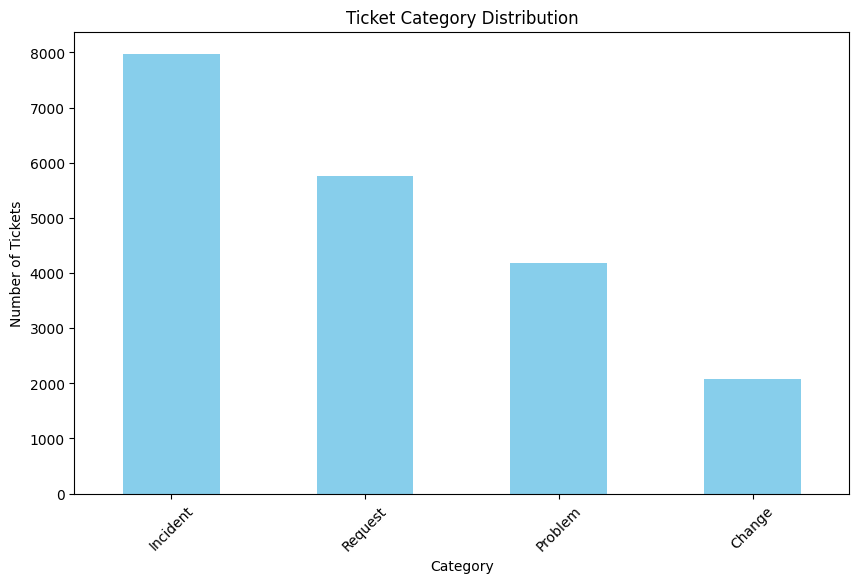

In [8]:
# ============================
# Cell 3 — Data Cleaning & Category Distribution
# ============================

import matplotlib.pyplot as plt

# 1️⃣ Combine 'subject' and 'body' into single text column
df['text'] = df['subject'].fillna('') + ' ' + df['body'].fillna('')

# 2️⃣ Create 'category' column from 'type'
df['category'] = df['type']

# 3️⃣ Drop rows where 'text' or 'category' is empty/null
df = df.dropna(subset=['text','category']).reset_index(drop=True)

# 4️⃣ Display info and nulls
print("Data Info:")
print(df.info())
print("\nMissing Values per Column:")
print(df.isnull().sum())

# 5️⃣ Plot category distribution
plt.figure(figsize=(10,6))
df['category'].value_counts().plot(kind='bar', title='Ticket Category Distribution', color='skyblue')
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

In [9]:
def assign_priority(text):
    text = str(text).lower()
    if "urgent" in text or "immediately" in text:
        return "High"
    elif "error" in text or "not working" in text:
        return "Medium"
    else:
        return "Low"

df['priority'] = df['text'].apply(assign_priority)
df[['text','priority']].head()

,text,priority
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Low
1,Customer Support Inquiry Seeking information o...,Low
2,Data Analytics for Investment I am contacting ...,Low
3,Krankenhaus-Dienstleistung-Problem Ein Medien-...,Low
4,"Security Dear Customer Support, I am reaching ...",Low


In [10]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)
df[['text','clean_text']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KAVIYA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,clean_text
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,unvorhergesehener absturz der datenanalyse pla...
1,Customer Support Inquiry Seeking information o...,customer support inquiry seeking information d...
2,Data Analytics for Investment I am contacting ...,data analytics investment contacting request i...
3,Krankenhaus-Dienstleistung-Problem Ein Medien-...,krankenhaus dienstleistung problem ein medien ...
4,"Security Dear Customer Support, I am reaching ...",security dear customer support reaching inquir...


In [11]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])

In [12]:
y_category = df['category']
y_priority = df['priority']

In [13]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X, y_category, test_size=0.2, random_state=42)
X_train_pri, X_test_pri, y_train_pri, y_test_pri = train_test_split(X, y_priority, test_size=0.2, random_state=42)

In [14]:
model_category = LogisticRegression(max_iter=1000)
model_category.fit(X_train_cat, y_train_cat)

model_priority = LogisticRegression(max_iter=1000)
model_priority.fit(X_train_pri, y_train_pri)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [15]:
y_pred_cat = model_category.predict(X_test_cat)
print("Category Model Performance:\n", classification_report(y_test_cat, y_pred_cat))

y_pred_pri = model_priority.predict(X_test_pri)
print("Priority Model Performance:\n", classification_report(y_test_pri, y_pred_pri))

Category Model Performance:
               precision    recall  f1-score   support

      Change       0.96      0.84      0.90       434
    Incident       0.73      0.89      0.80      1589
     Problem       0.63      0.35      0.45       807
     Request       0.95      0.99      0.97      1170

    accuracy                           0.80      4000
   macro avg       0.82      0.77      0.78      4000
weighted avg       0.80      0.80      0.79      4000

Priority Model Performance:
               precision    recall  f1-score   support

        High       0.99      0.74      0.84       170
         Low       0.98      1.00      0.99      3618
      Medium       0.96      0.80      0.87       212

    accuracy                           0.98      4000
   macro avg       0.98      0.85      0.90      4000
weighted avg       0.98      0.98      0.98      4000



In [16]:
def predict_ticket(text):
    cleaned = clean_text(text)
    vector = vectorizer.transform([cleaned])
    category = model_category.predict(vector)[0]
    priority = model_priority.predict(vector)[0]
    return category, priority

# Test
predict_ticket("Payment deducted but order not confirmed")

('Incident', 'Low')

In [19]:
# Cell 12 — Save trained models and vectorizer

import os
import joblib

# 1️⃣ Ensure folder exists
os.makedirs('model', exist_ok=True)

# 2️⃣ Save models
joblib.dump(model_category, "model/category_model.pkl")
joblib.dump(model_priority, "model/priority_model.pkl")
joblib.dump(vectorizer, "model/vectorizer.pkl")

print("Models and vectorizer saved successfully!")

Models and vectorizer saved successfully!


In [20]:
def predict_ticket(text):
    cleaned = clean_text(text)                  # Preprocess text
    vector = vectorizer.transform([cleaned])    # Convert to TF-IDF
    category = model_category.predict(vector)[0]
    priority = model_priority.predict(vector)[0]
    return category, priority

# Example
ticket_text = "My account login is not working and I need help immediately"
category, priority = predict_ticket(ticket_text)
print(f"Category: {category}, Priority: {priority}")

Category: Incident, Priority: Low


In [21]:
from sklearn.metrics import classification_report

# Category
y_pred_cat = model_category.predict(X_test_cat)
print("Category Model Performance:\n", classification_report(y_test_cat, y_pred_cat))

# Priority
y_pred_pri = model_priority.predict(X_test_pri)
print("Priority Model Performance:\n", classification_report(y_test_pri, y_pred_pri))

Category Model Performance:
               precision    recall  f1-score   support

      Change       0.96      0.84      0.90       434
    Incident       0.73      0.89      0.80      1589
     Problem       0.63      0.35      0.45       807
     Request       0.95      0.99      0.97      1170

    accuracy                           0.80      4000
   macro avg       0.82      0.77      0.78      4000
weighted avg       0.80      0.80      0.79      4000

Priority Model Performance:
               precision    recall  f1-score   support

        High       0.99      0.74      0.84       170
         Low       0.98      1.00      0.99      3618
      Medium       0.96      0.80      0.87       212

    accuracy                           0.98      4000
   macro avg       0.98      0.85      0.90      4000
weighted avg       0.98      0.98      0.98      4000



In [22]:
import joblib

category_model = joblib.load("model/category_model.pkl")
priority_model = joblib.load("model/priority_model.pkl")
vectorizer = joblib.load("model/vectorizer.pkl")

In [23]:
# Test new tickets
ticket_1 = "I cannot login to my account, urgent help needed"
ticket_2 = "Refund not processed for my last payment"
ticket_3 = "How do I change my account email?"

for ticket in [ticket_1, ticket_2, ticket_3]:
    category, priority = predict_ticket(ticket)
    print(f"Ticket: {ticket}\nPredicted Category: {category}, Priority: {priority}\n")

Ticket: I cannot login to my account, urgent help needed
Predicted Category: Incident, Priority: High

Ticket: Refund not processed for my last payment
Predicted Category: Incident, Priority: Low

Ticket: How do I change my account email?
Predicted Category: Incident, Priority: Low



In [24]:
from sklearn.metrics import classification_report

# Category model
y_pred_cat = model_category.predict(X_test_cat)
print("Category Model Performance:\n", classification_report(y_test_cat, y_pred_cat))

# Priority model
y_pred_pri = model_priority.predict(X_test_pri)
print("Priority Model Performance:\n", classification_report(y_test_pri, y_pred_pri))

Category Model Performance:
               precision    recall  f1-score   support

      Change       0.96      0.84      0.90       434
    Incident       0.73      0.89      0.80      1589
     Problem       0.63      0.35      0.45       807
     Request       0.95      0.99      0.97      1170

    accuracy                           0.80      4000
   macro avg       0.82      0.77      0.78      4000
weighted avg       0.80      0.80      0.79      4000

Priority Model Performance:
               precision    recall  f1-score   support

        High       0.99      0.74      0.84       170
         Low       0.98      1.00      0.99      3618
      Medium       0.96      0.80      0.87       212

    accuracy                           0.98      4000
   macro avg       0.98      0.85      0.90      4000
weighted avg       0.98      0.98      0.98      4000

